# Plot multi-lead predictions for predicting hurricane track (distance) errors.
author: Elizabeth A. Barnes and Randal J. Barnes

In [1]:
import sys

import pandas as pd

sys.path.append("..")

import importlib as imp

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from scipy.stats import multivariate_normal
from silence_tensorflow import silence_tensorflow
import pandas as pd
import cartopy as ct

import cmasher as cmr
import plots

import experiment_settings
import mahalanobis
from build_data import build_hurricane_data
import data_info

In [2]:
__author__ = "Randal J Barnes and Elizabeth A. Barnes"
__version__ = "07 September 2022"

silence_tensorflow()
tf.config.set_visible_devices([], "GPU")  # turn-off tensorflow-metal if it is on

DATA_PATH = "../data/"
MODEL_PATH = "saved_models/"
FIGURE_PATH = "figures/analysis_plots/"

In [3]:
mpl.rcParams["figure.facecolor"] = "white"
dpiFig = 300.0
np.warnings.filterwarnings("ignore", category=np.VisibleDeprecationWarning)

In [4]:
# EXP_NAME_VEC = ("centered_bivariate_normal_101_EPCP24",
#                 "centered_bivariate_normal_102_EPCP48",
#                 "centered_bivariate_normal_103_EPCP72",
#                 "centered_bivariate_normal_104_EPCP96",
#                 "centered_bivariate_normal_105_EPCP120",
#                 )
EXP_NAME_VEC = ("centered_bivariate_normal_201_AL24",
                "centered_bivariate_normal_202_AL48",
                "centered_bivariate_normal_203_AL72",
                "centered_bivariate_normal_204_AL96",
                "centered_bivariate_normal_205_AL120",
                )
RNG_SEED = 123
TESTING_YEAR = 2018
LONGITUDE_SCALING = -1.

In [5]:
# GET PREDICTIONS
df_pred_train = pd.DataFrame()
df_pred_valtest = pd.DataFrame()
df_pred_test = pd.DataFrame()

for exp_name in EXP_NAME_VEC:
    print(exp_name)
    settings = experiment_settings.get_settings(exp_name)

    network_seed = RNG_SEED
    settings["rng_seed"] = RNG_SEED
    settings["years_test"] = (TESTING_YEAR,)
    (
        data_summary,
        x_train,
        onehot_train,
        x_val,
        onehot_val,
        x_test,
        onehot_test,
        x_valtest,
        onehot_valtest,
        df_train,
        df_val,
        df_test,
        df_valtest,
    ) = build_hurricane_data(DATA_PATH, settings, verbose=0)

    # load the model
    model_name = (
            exp_name
            + "_"
            + str(TESTING_YEAR)
            + "_"
            + settings["uncertainty_type"]
            + "_"
            + f"network_seed_{network_seed}_rng_seed_{settings['rng_seed']}"
    )
    model = tf.keras.models.load_model(MODEL_PATH + model_name + "_model", compile=False)

    # make dictionary of the predictions
    pred_dict_lead = {"exp_name": exp_name,
                      "testing_year": TESTING_YEAR,
                      }

    # copy dataframe and fill in the predictions
    df_train_lt = df_train.copy()
    df_valtest_lt = df_valtest.copy()
    df_test_lt = df_test.copy()

    df_train_lt[["mu_u", "mu_v", "sigma_u", "sigma_v", "rho"]] = model.predict(x_train)
    df_valtest_lt[["mu_u", "mu_v", "sigma_u", "sigma_v", "rho"]] = model.predict(x_valtest)
    df_test_lt[["mu_u", "mu_v", "sigma_u", "sigma_v", "rho"]] = model.predict(x_test)

    df_train_lt["exp_name"] = exp_name
    df_valtest_lt["exp_name"] = exp_name
    df_test_lt["exp_name"] = exp_name

    # correct longitude for the Atlantic
    df_train_lt["LONC"] = df_train_lt["LONC"]*LONGITUDE_SCALING
    df_valtest_lt["LONC"] = df_valtest_lt["LONC"]*LONGITUDE_SCALING
    df_test_lt["LONC"] = df_test_lt["LONC"]*LONGITUDE_SCALING

    # append to main dataframe
    df_pred_train = pd.concat([df_pred_train, df_train_lt], axis=0)
    df_pred_valtest = pd.concat([df_pred_valtest, df_valtest_lt], axis=0)
    df_pred_test = pd.concat([df_pred_test, df_test_lt], axis=0)

centered_bivariate_normal_201_AL24
centered_bivariate_normal_202_AL48
centered_bivariate_normal_203_AL72
centered_bivariate_normal_204_AL96
centered_bivariate_normal_205_AL120


In [6]:
# error('here')

# Plot Results

In [7]:
# N_COLORS = 50
# colors = ("#D95980", "#284E60", "#284E60", "#C3B1E1", "#351F27", "#A9C961")
plots.set_plot_rc()

120 dataframe is empty


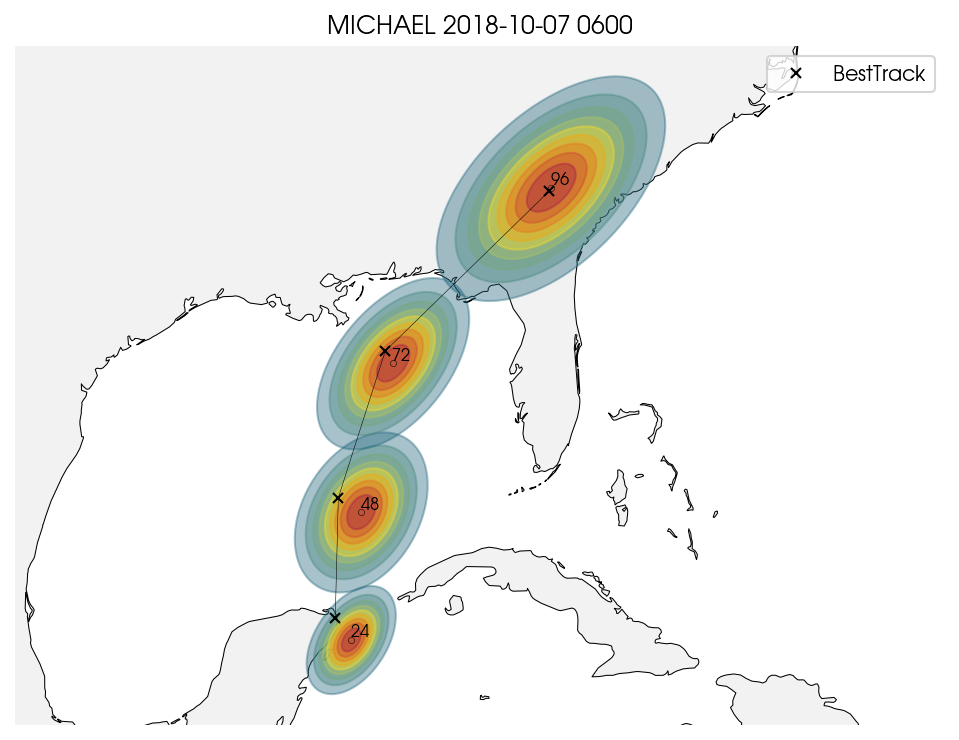

In [10]:
imp.reload(mahalanobis)
imp.reload(plots)

fig = plt.figure(figsize=(8, 6), dpi=150)
MAP_PROJ = ct.crs.EqualEarth(central_longitude = 0.)
ax = fig.add_subplot(1,1,1,projection=MAP_PROJ)

# storm_name = "NORMAN"
# pred_time = 90306
# KM_TO_DEG = 1. / 111

storm_name = "MICHAEL"
pred_time = 100706
df_storm = df_pred_test.loc[(df_pred_test["Name"] == storm_name) & (df_pred_test["time"] == pred_time)]
details = plots.plot_leadtime_predictions(df_storm,
                                          ax=ax,
                                          leadtimes=(24,48,72,96,120),
                                          )

# save the figure
plt.savefig(FIGURE_PATH + 'multi_lead_predictions_' + EXP_NAME_VEC[0] + '_' + details.replace(' ', '_') + '.png',
            dpi=dpiFig,
            bbox_inches='tight',
            )
plt.show()